# AmsterdamUMCdb Exploration

## Capstone Goal
Predict successful weaning from mechanical ventilation using time-series deep learning models.

## Objectives
- Understand database structure
- Identify ventilation-related tables
- Find extubation events
- Explore physiological measurements
- Understand timestamps and patient identifiers

### Imports

In [32]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import matplotlib.pyplot as plt

### Retrieving Google Project Id

In [33]:
client = bigquery.Client()

print("Connected to BigQuery")

Connected to BigQuery


In [34]:
# sets *your* project id
PROJECT_ID = "capstoneweaningprediction" #@param {type:"string"}

# Sets the default BigQuery dataset for accessing AmsterdamUMCdb

If you have received instructions to use a specific BigQuery instance, change the default settings here. Otherwise use these default values.

In [35]:
# sets default dataset for AmsterdamUMCdb
DATASET_PROJECT_ID = 'amsterdamumcdb' #@param {type:"string"}
DATASET_ID = 'version1_5_0' #@param {type:"string"}
LOCATION = 'eu' #@param {type:"string"}

# Provide your credentials to access the AmsterdamUMCdb dataset on Google BigQuery
Authenticate your credentials with Google Cloud Platform and set your default Google Cloud Project ID as an environment variable for running query jobs.

1. Run the cell. The `Allow this notebook to access your Google credentials?` prompt appears. Select `Allow`.
2. In the `Sign in - Google Accounts` dialog, use the account you registered during the AmsterdamUMCdb application process and select `Allow` again.

In [36]:
import os
from google.colab import auth

# all libraries check this environment variable, so set it:
os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID

auth.authenticate_user()
print('Authenticated')

Authenticated


# Enable data table display

Colab includes the `google.colab.data_table` package that can be used to display Pandas dataframes as an interactive data table (default limits: `max_rows = 20000`, `max_columns = 20`). This is especially useful when exploring the  tables or dictionary from AmsterdamUMCdb. It can be enabled with:

In [37]:
%load_ext google.colab.data_table
from google.colab.data_table import DataTable

# change default limits:
DataTable.max_columns = 50
DataTable.max_rows = 80000

The google.colab.data_table extension is already loaded. To reload it, use:
  %reload_ext google.colab.data_table



## Set the default query job configuration for magics

In [38]:
%load_ext bigquery_magics
from bigquery_magics import bigquery_magics
from google.cloud import bigquery

# sets the default query job configuration
def_config = bigquery.job.QueryJobConfig(default_dataset=DATASET_PROJECT_ID + "." + DATASET_ID)
bigquery_magics.context.default_query_job_config = def_config

The bigquery_magics extension is already loaded. To reload it, use:
  %reload_ext bigquery_magics


## Query the `person` table and copy the data to the `persons` Pandas dataframe:

The `person` table contains a record for each patient in AmsterdamUMCdb.

Since this is a relatively small table, it is acceptable to use `SELECT *`.

**Note**: Should an error occur while running the query, please see
the AmsterdamUMCdb BigQuery [Frequently Asked Questions](https://github.com/AmsterdamUMC/AmsterdamUMCdb/wiki/bigquery#faq).

In [39]:
%%bigquery person
SELECT * FROM `amsterdamumcdb.version1_5_0.person`;

Query is running:   0%|          |

Downloading:   0%|          |


## Set the default query job configuration for google-cloud-bigquery client

In [40]:
from google.cloud import bigquery

# BigQuery requires a separate config to prevent the 'BadRequest: 400 Cannot explicitly modify anonymous table' error message
job_config = bigquery.job.QueryJobConfig()

# sets default client settings by re-using the previously defined config
client = bigquery.Client(project=PROJECT_ID, location=LOCATION, default_query_job_config=def_config)

### List Tables

In [41]:
query = f"""
SELECT table_name
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
"""

tables = client.query(query).to_dataframe()

tables

,table_name
0,care_site
1,cdm_source
2,cohort
3,cohort_definition
4,concept
5,concept_ancestor
6,concept_class
7,concept_relationship
8,concept_synonym
9,condition_era


Step 1 — Explore Measurement Table

In [42]:
query = f"""
SELECT *
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement`
WHERE provider_id IS NOT NULL
LIMIT 10
"""

measurement_df = client.query(query).to_dataframe()

measurement_df.head()

,measurement_id,person_id,measurement_concept_id,measurement_date,measurement_datetime,measurement_time,measurement_type_concept_id,operator_concept_id,value_as_number,value_as_concept_id,...,provider_id,visit_occurrence_id,visit_detail_id,measurement_source_value,measurement_source_concept_id,unit_source_value,unit_source_concept_id,value_source_value,measurement_event_id,meas_event_field_concept_id
0,25659859,8166,46237002,2013-01-03,2013-01-03 02:03:00+00:00,02:03:00,32817,<NA>,None,36308950,...,40,9475,<NA>,GOS (Glasgow Outcome Score),<NA>,None,<NA>,3. Severe Disability,<NA>,<NA>
1,25659535,8166,46237002,2013-01-01,2013-01-01 04:03:00+00:00,04:03:00,32817,<NA>,None,36309649,...,40,9475,<NA>,GOS (Glasgow Outcome Score),<NA>,None,<NA>,2. Persistent vegetative state,<NA>,<NA>
2,25659686,8166,46237002,2013-01-02,2013-01-02 02:03:00+00:00,02:03:00,32817,<NA>,None,36309649,...,40,9475,<NA>,GOS (Glasgow Outcome Score),<NA>,None,<NA>,2. Persistent vegetative state,<NA>,<NA>
3,25659973,8166,46237002,2013-01-04,2013-01-04 02:03:00+00:00,02:03:00,32817,<NA>,None,36310710,...,40,9475,<NA>,GOS (Glasgow Outcome Score),<NA>,None,<NA>,5. Good Recovery,<NA>,<NA>
4,38399563,16815,46237002,2012-12-31,2012-12-31 13:17:00+00:00,13:17:00,32817,<NA>,None,36309649,...,40,19488,<NA>,GOS (Glasgow Outcome Score),<NA>,None,<NA>,2. Persistent vegetative state,<NA>,<NA>


In [43]:
measurement_df['measurement_source_concept_id'].unique()

<IntegerArray>
[<NA>]
Length: 1, dtype: Int64

### Inspect Columns

In [44]:
measurement_df.columns

Index(['measurement_id', 'person_id', 'measurement_concept_id',
       'measurement_date', 'measurement_datetime', 'measurement_time',
       'measurement_type_concept_id', 'operator_concept_id', 'value_as_number',
       'value_as_concept_id', 'unit_concept_id', 'range_low', 'range_high',
       'provider_id', 'visit_occurrence_id', 'visit_detail_id',
       'measurement_source_value', 'measurement_source_concept_id',
       'unit_source_value', 'unit_source_concept_id', 'value_source_value',
       'measurement_event_id', 'meas_event_field_concept_id'],
      dtype='object')

### Count total measurements

In [45]:
measurement_df.shape

(10, 23)

### Identify Most Common Measurements

In [46]:
query = f"""
SELECT
    c.concept_name,
    COUNT(*) as frequency
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
ON m.measurement_concept_id = c.concept_id
WHERE m.provider_id IS NOT NULL
GROUP BY c.concept_name
ORDER BY frequency DESC
LIMIT 50
"""

common_measurements = client.query(query).to_dataframe()

common_measurements

,concept_name,frequency
0,Urine output,3319256
1,Carbon dioxide production (VCO2) in Respirator...,3084460
2,Tidal volume inspired spontaneous+mechanical M...,2558732
3,Expired minute Volume during Mechanical ventil...,2558460
4,Tidal volume expired spontaneous+mechanical Re...,2558248
5,Inspired minute Volume during Mechanical venti...,2557314
6,Heart rate.beat-to-beat by EKG,2218626
7,Rise time setting Ventilator,2200447
8,Invasive Systolic blood pressure,2115980
9,Invasive Diastolic blood pressure,2115548


Ventilator parameters and continuous vitals dominate the top frequencies, reflecting the high-frequency logging of mechanically ventilated ICU patients.Ventilator parameters and continuous vitals dominate the top frequencies, reflecting the high-frequency logging of mechanically ventilated ICU patients. Lab values like electrolytes and coagulation markers appear less frequently, as they're drawn at discrete intervals rather than monitored continuously.

### Search Respiratory Measurements

In [47]:
query = f"""
SELECT
    DISTINCT concept_name
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.concept`
WHERE LOWER(concept_name) LIKE '%resp%'
"""

resp_measurements = client.query(query).to_dataframe()

resp_measurements

,concept_name
0,"No head, trunk, or leg response."
1,No response or unable to achieve state 4 durin...
2,No response; head hangs laterally or in flexion.
3,Head falls to side; no response in legs.
4,Other situations that may require binational n...
...,...
8518,"Poisoning by, adverse effect of and underdosin..."
8519,Other foreign object in other parts of respira...
8520,Gastric contents in other parts of respiratory...
8521,"Coma scale, best motor response"


### Explore Timestamp Distribution

In [48]:
query = f"""
SELECT
    measurement_datetime
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement`
WHERE provider_id = 40
LIMIT 100
"""

timestamp_dist = client.query(query).to_dataframe()

timestamp_dist

,measurement_datetime
0,2013-01-03 02:03:00+00:00
1,2013-01-01 04:03:00+00:00
2,2013-01-02 02:03:00+00:00
3,2013-01-04 02:03:00+00:00
4,2012-12-31 13:17:00+00:00
...,...
95,2013-01-04 19:21:00+00:00
96,2013-01-03 05:50:00+00:00
97,2013-01-02 05:50:00+00:00
98,2013-01-03 01:07:00+00:00


The timestamps are irregular, with readings clustered around recurring time-of-day slots that likely reflect shift-based charting rather than any fixed interval. This is expected in ICU data, where measurement frequency shifts with patient acuity — some days show multiple readings hours apart, others have much longer gaps.

### Measurement Frequency Per Patient

In [49]:
query = f"""
SELECT
    person_id,
    COUNT(*) as measurement_count
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement`
WHERE provider_id is not null
GROUP BY person_id
ORDER BY measurement_count DESC
LIMIT 20
"""

measurement_per_person = client.query(query).to_dataframe()

measurement_per_person

,person_id,measurement_count
0,9989,238314
1,19290,176589
2,7010,153074
3,15798,145608
4,5249,145004
5,3116,134473
6,9827,130166
7,7211,107297
8,617,104054
9,11991,100970


There's a stark density gap even within the top 20 — person 9989 has over 238k measurements while person 4353 sits at 81k, nearly a 3x difference, pointing to significant variation in ICU stay length or monitoring intensity. This kind of spread means any model trained on these sequences will need to handle highly variable sequence lengths rather than assuming uniform patient coverage.

### Explore Missingness

In [50]:
measurement_df.isnull().sum()

,0
measurement_id,0
person_id,0
measurement_concept_id,0
measurement_date,0
measurement_datetime,0
measurement_time,0
measurement_type_concept_id,0
operator_concept_id,10
value_as_number,10
value_as_concept_id,0


The missingness here is structural rather than random — fields like `value_as_number`, `unit_concept_id`, and `range_low/high` are consistently absent together, suggesting certain measurement types simply don't carry numeric values or units, which will push the decision toward exclusion or concept-level stratification before any filling strategy makes sense.

### Distribution of Physiological Variables

#### Heart-Rate Distribution

In [51]:
query = f"""
SELECT
    value_as_number
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
ON m.measurement_concept_id = c.concept_id
WHERE m.measurement_concept_id = 3027018
AND (m.provider_id IS NOT NULL OR m.provider_id IS NULL)
AND value_as_number IS NOT NULL
AND value_as_number > 0
LIMIT 1000
"""

heart_dist = client.query(query).to_dataframe()
heart_dist

,value_as_number
0,120.00000000000000000000000000000000000000
1,111.00000000000000000000000000000000000000
2,119.00000000000000000000000000000000000000
3,128.00000000000000000000000000000000000000
4,122.00000000000000000000000000000000000000
...,...
995,87.00000000000000000000000000000000000000
996,87.00000000000000000000000000000000000000
997,73.00000000000000000000000000000000000000
998,83.00000000000000000000000000000000000000


(array([  7.,  31., 129., 192., 206., 220., 162.,  41.,  10.,   2.]),
 array([ 34. ,  45.6,  57.2,  68.8,  80.4,  92. , 103.6, 115.2, 126.8,
        138.4, 150. ]),
 <BarContainer object of 10 artists>)

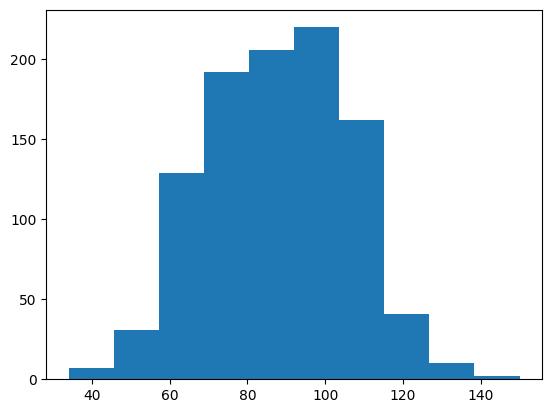

In [52]:
plt.hist(heart_dist['value_as_number'])

The distribution centers around 80-110 bpm, which is expected for ICU patients who tend to run slightly tachycardic. A small tail extends toward 140+ bpm representing genuinely elevated rates, while the few values below 40 are worth flagging as potential outliers or brief artefacts from monitoring interruptions.

#### Respiratoy-Rate Distribution

In [53]:
query = f"""
SELECT
    value_as_number
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
ON m.measurement_concept_id = c.concept_id
WHERE m.measurement_concept_id = 3024171
AND (m.provider_id IS NOT NULL OR m.provider_id IS NULL)
AND value_as_number IS NOT NULL
AND value_as_number > 0
LIMIT 1000
"""

rr_dist = client.query(query).to_dataframe()
rr_dist

,value_as_number
0,1.00000000000000000000000000000000000000
1,1.00000000000000000000000000000000000000
2,1.00000000000000000000000000000000000000
3,1.00000000000000000000000000000000000000
4,1.00000000000000000000000000000000000000
...,...
995,8.00000000000000000000000000000000000000
996,8.00000000000000000000000000000000000000
997,8.00000000000000000000000000000000000000
998,8.00000000000000000000000000000000000000


(array([121., 834.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  45.]),
 array([ 1. ,  6.9, 12.8, 18.7, 24.6, 30.5, 36.4, 42.3, 48.2, 54.1, 60. ]),
 <BarContainer object of 10 artists>)

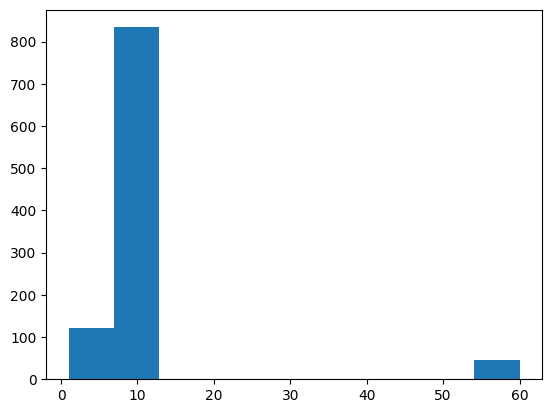

In [54]:
plt.hist(rr_dist['value_as_number'])

The distribution is heavily concentrated at exactly 10 breaths per minute with a small cluster at 60, which is not a natural physiological spread — this looks like default or manually entered values rather than continuously monitored data. The near-empty range between 10 and 60 confirms this concept is likely capturing spot-check or ventilator-set rates rather than true continuous respiratory monitoring in this datase

In [55]:
query = f"""
SELECT concept_id, concept_name, vocabulary_id, standard_concept
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.concept`
WHERE LOWER(concept_name) LIKE '%respiratory rate%'
AND standard_concept = 'S'
"""

concepts = client.query(query).to_dataframe()
concepts

,concept_id,concept_name,vocabulary_id,standard_concept
0,36310858,Assisted respiratory rate,LOINC,S
1,36310346,Unassisted respiratory rate,LOINC,S
2,36303374,Respiratory rate by Non-airway pressure measur...,LOINC,S
3,36305182,Respiratory rate --W exercise,LOINC,S
4,36305857,Respiratory rate --during anesthesia,LOINC,S
5,44811004,"CURB (confusion, urea, respiratory rate, blood...",SNOMED,S
6,42527123,Respiratory rate by Pulse oximetry.plethysmograph,LOINC,S
7,21490845,Respiratory rate by Acoustic measurement,LOINC,S
8,21490847,Respiratory rate by Carbon dioxide measurement,LOINC,S
9,21490867,Respiratory rate by Impedance.transthoracic,LOINC,S


#### SpO2 Distribution

In [58]:
# First check the concept ID
query = f"""
SELECT concept_id, concept_name, vocabulary_id, standard_concept
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.concept`
WHERE LOWER(concept_name) LIKE '%oxygen saturation%'
AND standard_concept = 'S'
"""
concepts = client.query(query).to_dataframe()
concepts

,concept_id,concept_name,vocabulary_id,standard_concept
0,37159835,Oxygen saturation (oxygenated haemoglobin/deox...,SNOMED,S
1,37170618,SvO2 (mixed venous oxygen saturation) percent ...,SNOMED,S
2,36717886,Outlet blood oxygen saturation,OMOP Extension,S
3,36717891,Pre-membrane lung oxygen saturation,OMOP Extension,S
4,36717895,Post-membrane lung oxygen saturation,OMOP Extension,S
...,...,...,...,...
130,40762503,Oxygen saturation in Arterial blood by Pulse o...,LOINC,S
131,40762507,Oxygen saturation in Arterial blood by Pulse o...,LOINC,S
132,40762497,Oxygen saturation (8 hour minimum) in Arterial...,LOINC,S
133,40762500,Oxygen saturation in Arterial blood by Pulse o...,LOINC,S


In [59]:
query = f"""
SELECT
    value_as_number,
    unit_source_value,
    unit_concept_id
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
WHERE m.measurement_concept_id = 40762499
AND (m.provider_id IS NOT NULL OR m.provider_id IS NULL)
AND value_as_number IS NOT NULL
LIMIT 1000
"""

spo2_dist = client.query(query).to_dataframe()
spo2_dist

,value_as_number,unit_source_value,unit_concept_id
0,0E-38,None,8554
1,0E-38,None,8554
2,0E-38,None,8554
3,0E-38,None,8554
4,0E-38,None,8554
...,...,...,...
995,77.00000000000000000000000000000000000000,None,8554
996,77.00000000000000000000000000000000000000,None,8554
997,77.00000000000000000000000000000000000000,None,8554
998,77.00000000000000000000000000000000000000,None,8554


(array([ 29.,  12.,  23.,  18.,  26.,  52.,  75.,  97., 192., 476.]),
 array([ 0. ,  7.7, 15.4, 23.1, 30.8, 38.5, 46.2, 53.9, 61.6, 69.3, 77. ]),
 <BarContainer object of 10 artists>)

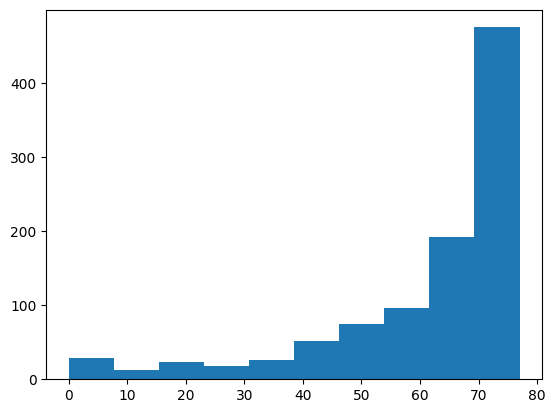

In [60]:
plt.hist(spo2_dist['value_as_number'])

The distribution is heavily right-skewed with the vast majority of values clustering at 90-100%, which is exactly where you'd expect a well-managed ICU population to sit with supplemental oxygen support. The sparse values below 70% are worth flagging — they could be genuine desaturation events during critical moments, or sensor artefacts from poor probe contact.

Selected patient: 16921


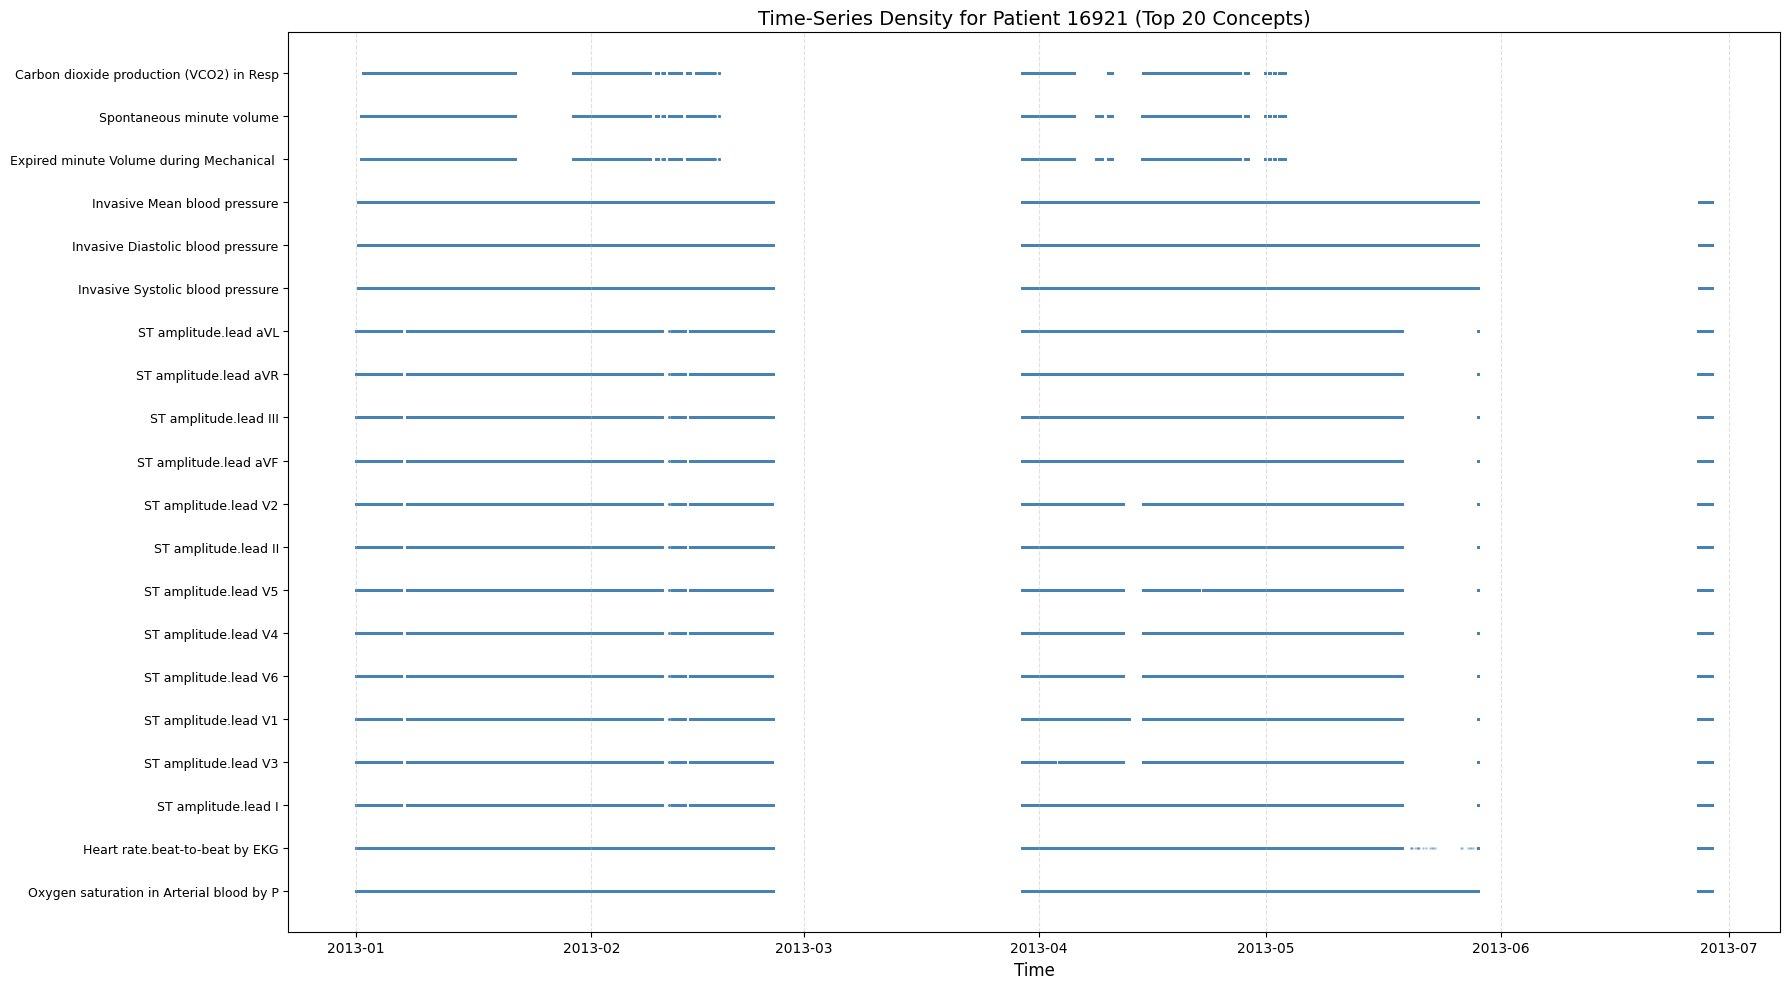

Gap statistics (minutes):
count    7.127232e+06
mean     3.638986e-02
std      1.594097e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.007200e+04
Name: gap_minutes, dtype: float64

Largest gaps (hours):
4011491    501.2
7052663    459.4
7052697    132.8
7052702     89.8
4011497     66.6
Name: gap_minutes, dtype: float64


In [61]:
# Step 1: Pick a patient with many measurements
query = f"""
SELECT
    person_id,
    COUNT(*) as measurement_count
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement`
WHERE (provider_id IS NOT NULL OR provider_id IS NULL)
GROUP BY person_id
ORDER BY measurement_count DESC
LIMIT 1
"""
top_patient = client.query(query).to_dataframe()
patient_id = top_patient['person_id'].values[0]
print(f"Selected patient: {patient_id}")

# Step 2: Pull all measurements for that patient
query = f"""
SELECT
    measurement_datetime,
    value_as_number,
    c.concept_name
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
ON m.measurement_concept_id = c.concept_id
WHERE m.person_id = {patient_id}
AND (m.provider_id IS NOT NULL OR m.provider_id IS NULL)
AND value_as_number IS NOT NULL
ORDER BY measurement_datetime
"""
patient_ts = client.query(query).to_dataframe()

# Step 3: Visualize time-series density
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

patient_ts['measurement_datetime'] = pd.to_datetime(patient_ts['measurement_datetime'])

# Get top 20 most frequent concepts for readability
top_concepts = patient_ts['concept_name'].value_counts().head(20).index
filtered_ts = patient_ts[patient_ts['concept_name'].isin(top_concepts)]

# Shorten long concept names
filtered_ts = filtered_ts.copy()
filtered_ts['concept_short'] = filtered_ts['concept_name'].str[:40]

plt.figure(figsize=(18, 10))
concepts = filtered_ts['concept_short'].unique()
concept_map = {c: i for i, c in enumerate(concepts)}

plt.scatter(
    filtered_ts['measurement_datetime'],
    filtered_ts['concept_short'].map(concept_map),
    s=1, alpha=0.3, color='steelblue'
)

plt.yticks(range(len(concepts)), concepts, fontsize=9)
plt.xlabel('Time', fontsize=12)
plt.title(f'Time-Series Density for Patient {patient_id} (Top 20 Concepts)', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Step 4: Check gaps between consecutive measurements
patient_ts_sorted = patient_ts.sort_values('measurement_datetime')
patient_ts_sorted['gap_minutes'] = patient_ts_sorted['measurement_datetime'].diff().dt.total_seconds() / 60
print("Gap statistics (minutes):")
print(patient_ts_sorted['gap_minutes'].describe())
print(f"\nLargest gaps (hours):")
print((patient_ts_sorted['gap_minutes'].nlargest(5) / 60).round(1))

The plot reveals two distinct ICU admission periods — a dense monitoring block from January to February 2013, then a gap, followed by another from April to May…The plot reveals two distinct ICU admission periods — a dense monitoring block from January to February 2013, then a gap, followed by another from April to May 2013, suggesting either a readmission or a transfer. The gap statistics confirm this, with a maximum gap of 501 hours (~3 weeks) and a median of zero, meaning when this patient was being monitored the measurements were nearly continuous, but the inter-admission silence is substantial — exactly the kind of discontinuity that needs to be handled carefully before feeding sequences into an LSTM/GRU.